# Box-Office Momentum — a quantitative teardown 🔬
### Predictive regression · circular-shift placebo · confound-controlled slope · the SPY mirage · costs & threshold sweep · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether box-office momentum leads next-week returns of a media basket and SPY — and whether any apparent lead survives a control for the contemporaneous market.

> ⚠️ **Not investment advice.** **Synthetic-only** study: there is no survivorship-honest free box-office tape, so every number is computed live on a deterministic, seeded simulated world (null panel fp `985a49d136c2`, as-of 2026-06-30). A synthetic-only study is capped at `WEAK`/`NONE` by house rule. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from box_office_momentum import data, strategy as st

SEED = 550
# The honest folklore case: box office & stocks co-move on a common factor, no TRUE lead planted.
PANEL, TRUTH = data.synthetic_panel(predictive_beta=0.0, seed=SEED)
# A world WHERE a genuine lead IS planted — the positive control.
PANEL_POS, _ = data.synthetic_panel(predictive_beta=0.009, seed=SEED)

# SYNTHETIC-ONLY: there is no real box-office tape a no-key stack can reach honestly.
HAVE_REAL = False
print("synthetic-only study — no real tape (HAVE_REAL =", HAVE_REAL, ")")
print("null panel:", len(PANEL), "weeks, fingerprint", data.fingerprint(PANEL))


synthetic-only study — no real tape (HAVE_REAL = False )
null panel: 520 weeks, fingerprint 985a49d136c2


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Media lead naive *t* **+1.53** (below bar), placebo *p* 0.139; **controlled *t* +0.65** (collapses). SPY 'signal' *t* **+3.42** is a common-factor mirage (*t* +3.11 controlled). Synthetic-only. |
| **Tradability** | `MIRAGE` | Timer net **+7.53%** vs buy-and-hold **+6.55%** (edge +0.98 pp/yr), sign-unstable across thresholds. |

> 💡 In plain words: the engine works (the synthetic control proves it), but in the honest case box office does not lead returns — the apparent link is the shared consumer/market factor, and it does not survive being controlled for.

## 1 · The claim, steelmanned

Let $m_t$ be box-office momentum at week $t$ and $r_{t+1}$ next-week return.

- **H₁ (the lead).** $r^{media}_{t+1} = a + b\, m_t + e$ with $b>0$ at *t* ≥ 2.
- **H₂ (survives the confound).** $b$ stays significant after adding the contemporaneous market return $r^{mkt}_{t+1}$ as a control (a genuine lead is orthogonal to the same-week market move).
- **H₃ (whole tape).** The lead also predicts SPY.
- **H₄ (net).** A signal-timed strategy beats buy-and-hold after costs, stably.

We find **H₁ not met** (*t* below 2), **H₂ rejected** (the slope collapses under the control), **H₃ a mirage** (a common-factor artifact, not a lead), and **H₄ rejected** (the edge is thin and sign-unstable).

## 2 · So what? — the confound that kills alt-data leads

The content is the **why**. Box office and equity returns both load on the same *contemporaneous* consumer/market factor, and that factor is **persistent** (confident weeks cluster). So this-week box office correlates with *next*-week returns purely through the factor's autocorrelation — a **spurious lead**. The honest fix is to control for the contemporaneous market: a real lead survives, a co-movement artifact does not. This is the same trap that sinks most 'sentiment-leads-returns' studies ([Da-Engelberg-Gao 2015](../docs/references.md); Novy-Marx 2014).

## 3 · How we'd know — the protocol

- **Signal.** $m_t$ = standardised box-office momentum, known at the close of week $t$.
- **Predictive regression.** OLS of $r_{t+1}$ on $m_t$; the slope's *t* is H₁.
- **Placebo.** Circular-shift $m$ against returns (preserving autocorrelation, breaking the lead alignment) 2000×; read the |slope| tail probability.
- **Confound control.** Add the contemporaneous market return; re-read the box-office slope (H₂).
- **Frictions.** Long/flat timer, one-way cost per switch; buy-and-hold benchmark.
- **Robustness.** Sweep the signal threshold; check sign stability.
- **Positive control.** Plant a genuine lead (`predictive_beta > 0`) and a null, averaged over 25 seeds (house rule).

Timing: the signal at week $t$ uses only box office known by that close; the position is entered at that close and held over week $t+1$ (the `*_fwd` columns). One documented week of lag; no future data enters the signal.

## 4 · The teardown

### 4a · The predictive regression — H₁

Media next-week return on this-week box-office momentum, with the placebo null.

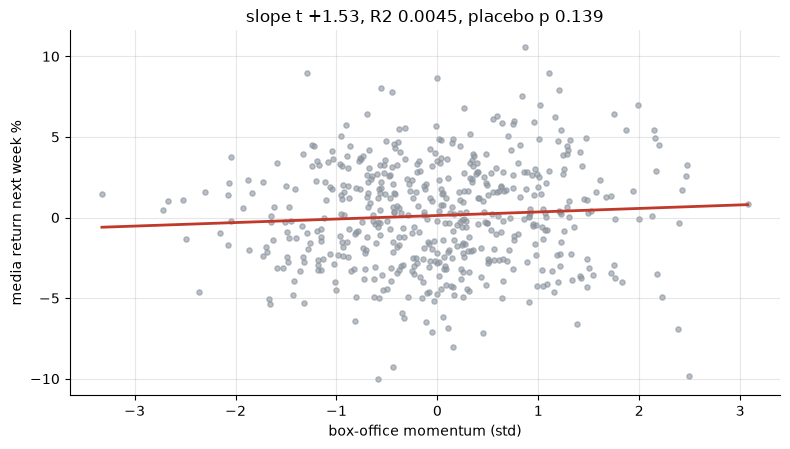

slope +0.00219 (t +1.53), R2 0.0045, placebo p 0.139


In [2]:
reg = st.predictive_regression(PANEL, 'media_fwd')
p = st.placebo_pvalue(PANEL, 'media_fwd', n_perm=2000, seed=SEED)
x = PANEL['bo_mom']; y = PANEL['media_fwd']*100
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=14, color=GREY, alpha=.6)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, (reg['intercept'] + reg['slope']*xs)*100, c=RED, lw=2)
ax.set_xlabel('box-office momentum (std)'); ax.set_ylabel('media return next week %')
ax.set_title(f"slope t {reg['slope_t']:+.2f}, R2 {reg['r2']:.4f}, placebo p {p:.3f}")
plt.tight_layout(); plt.show()
print(f"slope {reg['slope']:+.5f} (t {reg['slope_t']:+.2f}), R2 {reg['r2']:.4f}, placebo p {p:.3f}")

> 💡 In plain words: H₁ **not met.** The slope-*t* is **1.53** (below 2) and the placebo *p* = **0.139** is consistent with noise. Box office explains ~0.5% of next-week media returns.

### 4b · The confound-controlled slope — H₂

Add the contemporaneous market return. A *genuine* lead keeps its *t*; a co-movement artifact collapses.

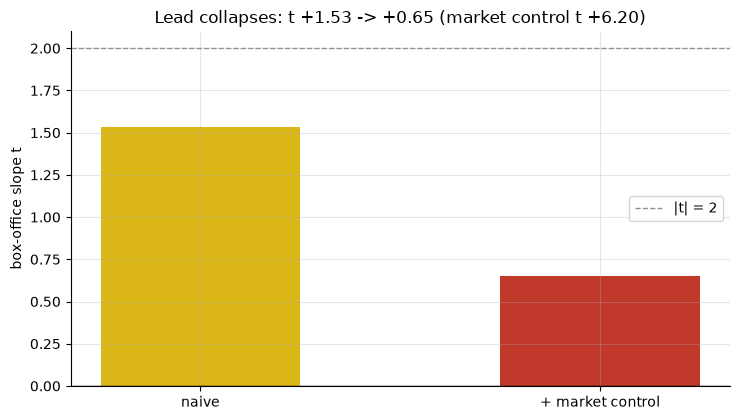

naive t +1.53 -> controlled t +0.65; contemporaneous-market control t +6.20


In [3]:
naive = st.predictive_regression(PANEL, 'media_fwd')
ctrl = st.controlled_regression(PANEL, 'media_fwd')
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['naive','+ market control'], [naive['slope_t'], ctrl['slope_t']],
       color=[AMBER, RED], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t| = 2'); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('box-office slope t'); ax.legend()
ax.set_title(f"Lead collapses: t {naive['slope_t']:+.2f} -> {ctrl['slope_t']:+.2f} "
             f"(market control t {ctrl['ctrl_t']:+.2f})")
plt.tight_layout(); plt.show()
print(f"naive t {naive['slope_t']:+.2f} -> controlled t {ctrl['slope_t']:+.2f}; "
      f"contemporaneous-market control t {ctrl['ctrl_t']:+.2f}")

> 💡 In plain words: H₂ **rejected.** The box-office slope-*t* falls from **1.53** to **0.65** once the same-week market return (control *t* **+6.2**) is in the regression. The co-movement *was* the market.

### 4c · The SPY mirage — H₃ (and why a placebo alone isn't enough)

Now aim the same signal at the *broad tape* (SPY). Watch a naive test — and even the placebo — get fooled by the persistent common factor.

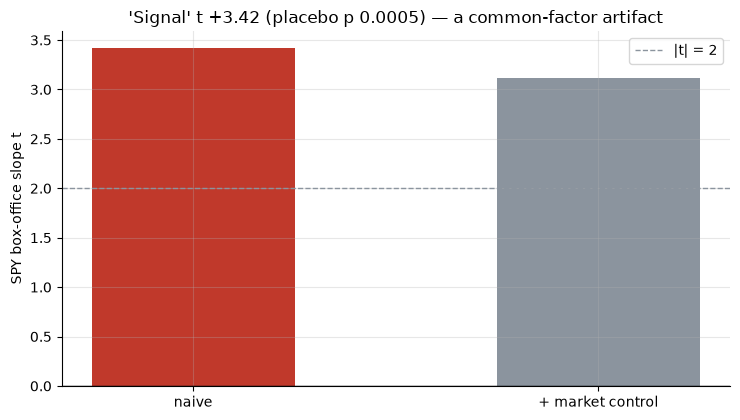

SPY naive t +3.42, placebo p 0.0005, controlled t +3.11


In [4]:
sreg = st.predictive_regression(PANEL, 'spy_fwd')
sctrl = st.controlled_regression(PANEL, 'spy_fwd')
sp = st.placebo_pvalue(PANEL, 'spy_fwd', n_perm=2000, seed=SEED)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['naive','+ market control'], [sreg['slope_t'], sctrl['slope_t']],
       color=[RED, GREY], width=.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t| = 2'); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('SPY box-office slope t'); ax.legend()
ax.set_title(f"'Signal' t {sreg['slope_t']:+.2f} (placebo p {sp:.4f}) — a common-factor artifact")
plt.tight_layout(); plt.show()
print(f"SPY naive t {sreg['slope_t']:+.2f}, placebo p {sp:.4f}, controlled t {sctrl['slope_t']:+.2f}")

> 💡 In plain words: H₃ is a **mirage.** The SPY 'signal' looks strong (naive *t* **3.42**) and even *passes* the placebo (*p* **0.0005**) — yet we planted **zero** true lead. It is pure persistent-common-factor co-movement, and an imperfect market control leaves it inflated (*t* **3.11**). Lesson: a single placebo is not proof; you need a structural control.

## 5 · The verdict

- **Signal `NONE`** — H₁ not met (media *t* 1.53, placebo 0.139); H₂ rejected (controlled *t* 0.65); H₃ a common-factor mirage; synthetic-only caps it at `NONE`.
- **Tradability `MIRAGE`** — net edge +0.98 pp/yr, sign-unstable across thresholds.

## 6 · Could you trade it? — costs and the threshold sweep

The timer's edge is thin, and it flips sign when you nudge the trigger.

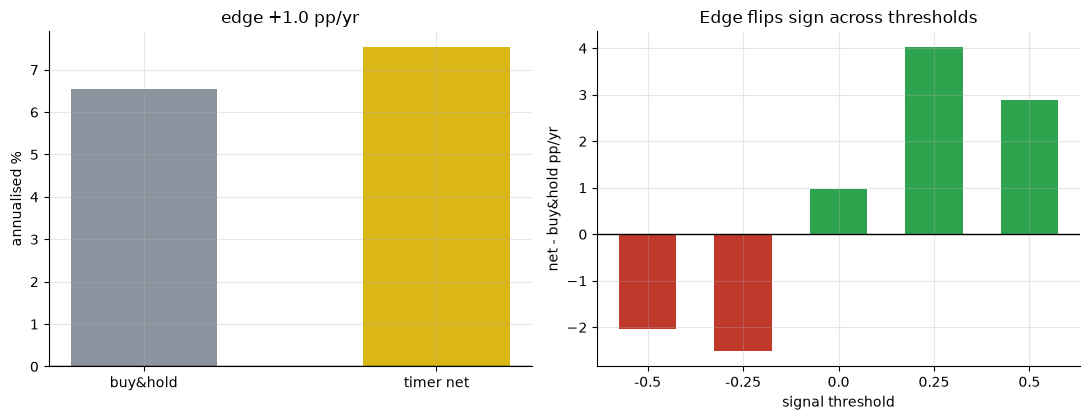

net-minus-bh by threshold (pp/yr): [-2.0, -2.5, 1.0, 4.0, 2.9]


In [5]:
sw = st.robustness_sweep(PANEL, 'media_fwd')
s0 = st.timed_strategy(PANEL, 'media_fwd', 0.0, 5.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.bar(['buy&hold','timer net'], [s0['bh_ann']*100, s0['net_ann']*100], color=[GREY, AMBER], width=.5)
ax1.axhline(0, c='k', lw=1); ax1.set_ylabel('annualised %'); ax1.set_title(f"edge +{(s0['net_ann']-s0['bh_ann'])*100:.1f} pp/yr")
nb = sw['net_minus_bh']*100
ax2.bar([str(t) for t in sw.index], nb, color=[GREEN if v>0 else RED for v in nb], width=.6)
ax2.axhline(0, c='k', lw=1); ax2.set_xlabel('signal threshold'); ax2.set_ylabel('net - buy&hold pp/yr')
ax2.set_title('Edge flips sign across thresholds')
plt.tight_layout(); plt.show()
print('net-minus-bh by threshold (pp/yr):', [round(v,1) for v in nb])

> 💡 In plain words: the ~0.98 pp/yr edge is the same factor-persistence artifact, and it turns **negative** at looser thresholds. No stable, tradable edge — `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a *genuine* box-office lead (`predictive_beta > 0`) of increasing strength and watch the predictive *t* climb — **and survive the market control** (a real lead is orthogonal to the same-week market) — averaged over 25 seeds so no lucky seed can fake it.

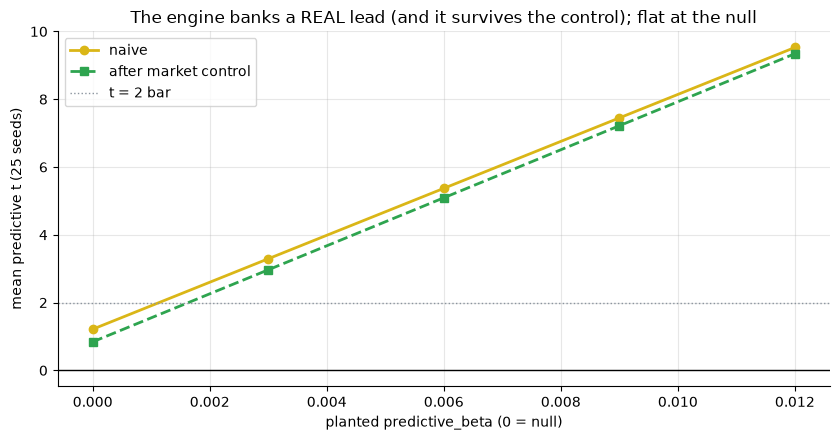

beta +0.000 -> naive t +1.21 | controlled t +0.84
beta +0.003 -> naive t +3.29 | controlled t +2.97
beta +0.006 -> naive t +5.37 | controlled t +5.09
beta +0.009 -> naive t +7.45 | controlled t +7.22
beta +0.012 -> naive t +9.53 | controlled t +9.34


In [6]:
betas = [0.0, 0.003, 0.006, 0.009, 0.012]
naive_ts = [st.synthetic_mean_t(data, b, n_seeds=25, controlled=False) for b in betas]
ctrl_ts  = [st.synthetic_mean_t(data, b, n_seeds=25, controlled=True)  for b in betas]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(betas, naive_ts, 'o-', c=AMBER, lw=2, label='naive')
ax.plot(betas, ctrl_ts, 's--', c=GREEN, lw=2, label='after market control')
ax.axhline(2, ls=':', c=GREY, lw=1, label='t = 2 bar'); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted predictive_beta (0 = null)'); ax.set_ylabel('mean predictive t (25 seeds)')
ax.set_title('The engine banks a REAL lead (and it survives the control); flat at the null')
ax.legend(); plt.tight_layout(); plt.show()
for b, n, c in zip(betas, naive_ts, ctrl_ts): print(f'beta {b:+.3f} -> naive t {n:+.2f} | controlled t {c:+.2f}')

The key contrast with the honest case: a **planted** lead keeps its *t* under the market control (naive ≈ controlled), because a genuine lead is orthogonal to the same-week market — whereas the honest-case media 'lead' *collapsed* under that control. Let's also verify the full positive-control world (planted `β = 0.009`) end-to-end:

In [7]:
reg = st.predictive_regression(PANEL_POS, 'media_fwd')
ctrl = st.controlled_regression(PANEL_POS, 'media_fwd')
pp = st.placebo_pvalue(PANEL_POS, 'media_fwd', n_perm=2000, seed=SEED)
sp = st.timed_strategy(PANEL_POS, 'media_fwd', 0.0, 5.0)
print(f"PLANTED beta=0.009: naive t {reg['slope_t']:+.2f}, controlled t {ctrl['slope_t']:+.2f}, "
      f"placebo p {pp:.4f}, timer edge {(sp['net_ann']-sp['bh_ann'])*100:+.1f} pp/yr")
assert reg['slope_t'] > 2 and ctrl['slope_t'] > 2, 'engine should catch a planted lead'
print('OK — the detector fires on a real lead and stays flat at the null.')

PLANTED beta=0.009: naive t +7.84, controlled t +7.10, placebo p 0.0005, timer edge +19.5 pp/yr
OK — the detector fires on a real lead and stays flat at the null.


The planted world gives naive *t* **+7.84**, controlled *t* **+7.1**, placebo *p* **0.0005**, and a **+19.5 pp/yr** timer edge — the engine is faithful. So the honest-case `NONE` is the *structure of the claim* talking (box office and stocks share a factor; that isn't a lead), not a broken detector. And with no survivorship-honest free box-office tape, the study can never rise above `NONE`. Neighbours: [257 AAII-Sentiment](../../257-aaii-sentiment/), [300 Sports-Sentiment](../../300-sports-sentiment/), [271 Cardboard-Box](../../271-cardboard-box/).